# Más vegetación, ¿menos caudal? Los datos dicen lo contrario en zonas secas

**47,4% de las cuencas que se volvieron más verdes — y donde sube la evaporación (E) — también llevan MÁS caudal (Q), no menos.** El patrón se invierte exactamente donde la teoría tradicional decía que sería peor: en zonas semiáridas y áridas.

> **Paper**: Tian, L. et al. (2026). *Energy-mediated feedbacks of vegetation greening enhance precipitation efficiency and sustain water yield in global semi-arid regions*. **Nature Water**.
>
> **DOI**: [10.1038/s44221-026-00631-y](https://doi.org/10.1038/s44221-026-00631-y)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-22-greening-no-seca-rios-semiaridos/notebook.ipynb)

🎬 *Video corto pendiente.*


## El supuesto que se rompe

Durante décadas, la regla parecía clara: si plantas árboles, el suelo retiene menos agua y los ríos llevan menos caudal. Las plantas transpiran, devuelven humedad al aire, y eso reduce el flujo aguas abajo. Un *trade-off* aparente entre restauración ecológica y agua disponible.

Tian y su equipo agarraron **4.080 cuencas hidrográficas** repartidas por el mundo y las cruzaron con simulaciones que conectan tierra y atmósfera. Lo que encontraron desafía la intuición — justo donde se temía el peor *trade-off*.


In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
TOTAL_CUENCAS = 4080
CUENCAS_E_Q_SUBE = 1934
PCT_HEADLINE = 47.4
COLOR_GREEN = '#059669'       # E↑Q↑ (verdor con caudal subiendo)
COLOR_LOSS = '#DC2626'        # E↑Q↓ (caudal cayendo)
COLOR_REF = '#D97706'         # umbral / referencia
COLOR_DATA = '#2563EB'        # datos principales
COLOR_CONTEXT = '#7C3AED'     # series secundarias
FUENTE = 'Fuente: Tian et al. (2026), Nature Water | DOI: 10.1038/s44221-026-00631-y'

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Cargar estilo CaM (local primero, fallback GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
import matplotlib
plt.rcParams['figure.dpi'] = 80
plt.rcParams['savefig.dpi'] = 200
plt.style.use(style_file)

# Cargar los 5 datasets
aridez = pd.read_csv('datos/cuencas_por_aridez.csv')
cuencas = pd.read_csv('datos/cuencas_lai_q_e.csv')
lp = pd.read_csv('datos/lp_descomposicion.csv')
hotspots = pd.read_csv('datos/regiones_descomposicion.csv')
serie = pd.read_csv('datos/serie_global_E_Q.csv')

print(f'Cuencas globales con verdor + E↑: {len(cuencas):,}')
print(f'De ellas, con caudal Q↑: {(cuencas["q_slope_mm_yr2"] > 0).sum():,} '
      f'({(cuencas["q_slope_mm_yr2"] > 0).mean()*100:.1f}%)')
print(f'Bins por aridez: {list(aridez["aridez"])}')
print(f'Hotspots con descomposición: {hotspots["Region"].unique().tolist()}')


Cuencas globales con verdor + E↑: 4,080
De ellas, con caudal Q↑: 1,934 (47.4%)
Bins por aridez: ['Arid', 'Semi-Arid', 'Sub-Humid', 'Humid']
Hotspots con descomposición: ['Loess Plateau', 'India', 'Australia', 'Mexico', 'United States']


## Aquí está.


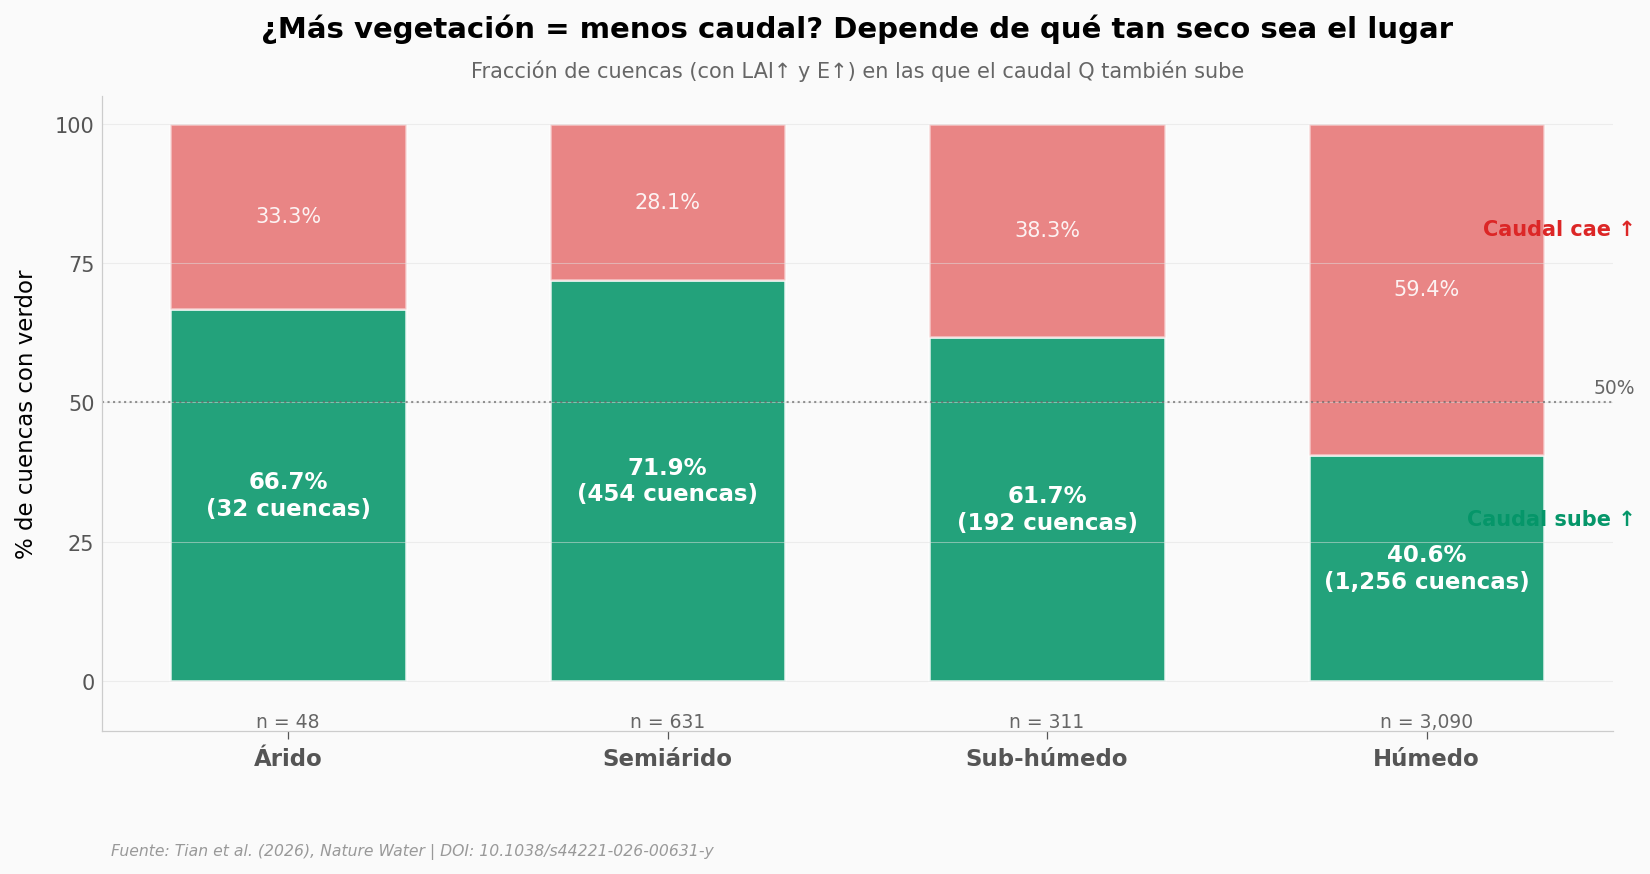

In [2]:
plt.close('all')
fig, ax = plt.subplots(figsize=(13, 5.5))

orden = ['Arid', 'Semi-Arid', 'Sub-Humid', 'Humid']
labels_es = ['Árido', 'Semiárido', 'Sub-húmedo', 'Húmedo']
df_orden = aridez.set_index('aridez').loc[orden].reset_index()

pct_q_sube = df_orden['pct_E_sube_Q_sube'].values
pct_q_baja = 100 - pct_q_sube
totales = df_orden['total_greening'].values

x = np.arange(len(orden))
width = 0.62

bars_sube = ax.bar(x, pct_q_sube, width, color=COLOR_GREEN, alpha=0.88,
                   edgecolor='white', linewidth=1.2, label='Caudal SUBE (E↑Q↑)')
bars_baja = ax.bar(x, pct_q_baja, width, bottom=pct_q_sube, color=COLOR_LOSS, alpha=0.55,
                   edgecolor='white', linewidth=1.2, label='Caudal BAJA (E↑Q↓)')

# Línea de referencia 50%
ax.axhline(50, color='#666666', linewidth=1.0, linestyle=':', alpha=0.7, zorder=2)
ax.text(3.55, 51, '50%', fontsize=9, color='#666666', va='bottom', ha='right')

# Etiquetas dentro de las barras: % y conteo
for i, (p_sube, total) in enumerate(zip(pct_q_sube, totales)):
    n_sube = df_orden['cuencas_E_sube_Q_sube'].iloc[i]
    ax.text(i, p_sube/2, f'{p_sube:.1f}%\n({n_sube:,} cuencas)',
            ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    ax.text(i, p_sube + (100 - p_sube)/2, f'{100-p_sube:.1f}%',
            ha='center', va='center', fontsize=10, color='white', alpha=0.9)
    # Totales bajo cada barra
    ax.text(i, -5.5, f'n = {total:,}', ha='center', va='top', fontsize=9, color='#666666')

ax.set_xticks(x)
ax.set_xticklabels(labels_es, fontsize=11, fontweight='bold')
ax.set_ylabel('% de cuencas con verdor', fontsize=11)
ax.set_ylim(-9, 105)
ax.set_yticks([0, 25, 50, 75, 100])
ax.set_title('¿Más vegetación = menos caudal? Depende de qué tan seco sea el lugar',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Fracción de cuencas (con LAI↑ y E↑) en las que el caudal Q también sube',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Inline labels (axes-coords correctas: 0-1 en x, 0-1 en y → uso data-coords directos)
ax.text(3.55, 28, 'Caudal sube ↑', fontsize=10,
        color=COLOR_GREEN, fontweight='bold', ha='right')
ax.text(3.55, 80, 'Caudal cae ↑', fontsize=10,
        color=COLOR_LOSS, fontweight='bold', ha='right')

fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/pct_q_sube_por_aridez.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)


### Lo que llama la atención

El patrón que esperaríamos — más vegetación, menos caudal — **solo aparece donde menos importaba**: en cuencas húmedas, ya con agua de sobra. Donde el agua sí es escasa, la dirección se invierte.

- **Semiárido**: 71,9% de las cuencas con verdor también tienen caudal subiendo (454 de 631).
- **Árido**: 66,7% (32 de 48). Muestra pequeña, pero apunta al mismo patrón.
- **Sub-húmedo**: 61,7% (192 de 311).
- **Húmedo**: 40,6% (1.256 de 3.090). Aquí sí aparece la mayoría con caudal cayendo, pero por poco.

La regla del *trade-off* — plantar más → menos agua río abajo — funciona como guía cuando ya sobra humedad, pero no captura lo que ocurre en las regiones secas.


## ¿Por qué pasa esto? El caso de la meseta de Loess

Ahora la pregunta es **qué mecanismo** hay detrás. Para eso, el equipo corrió una simulación acoplada tierra–atmósfera sobre la **Meseta de Loess** en China — la mayor revegetación del planeta — y partió el aumento de lluvia atribuido al verdor en tres aportes.


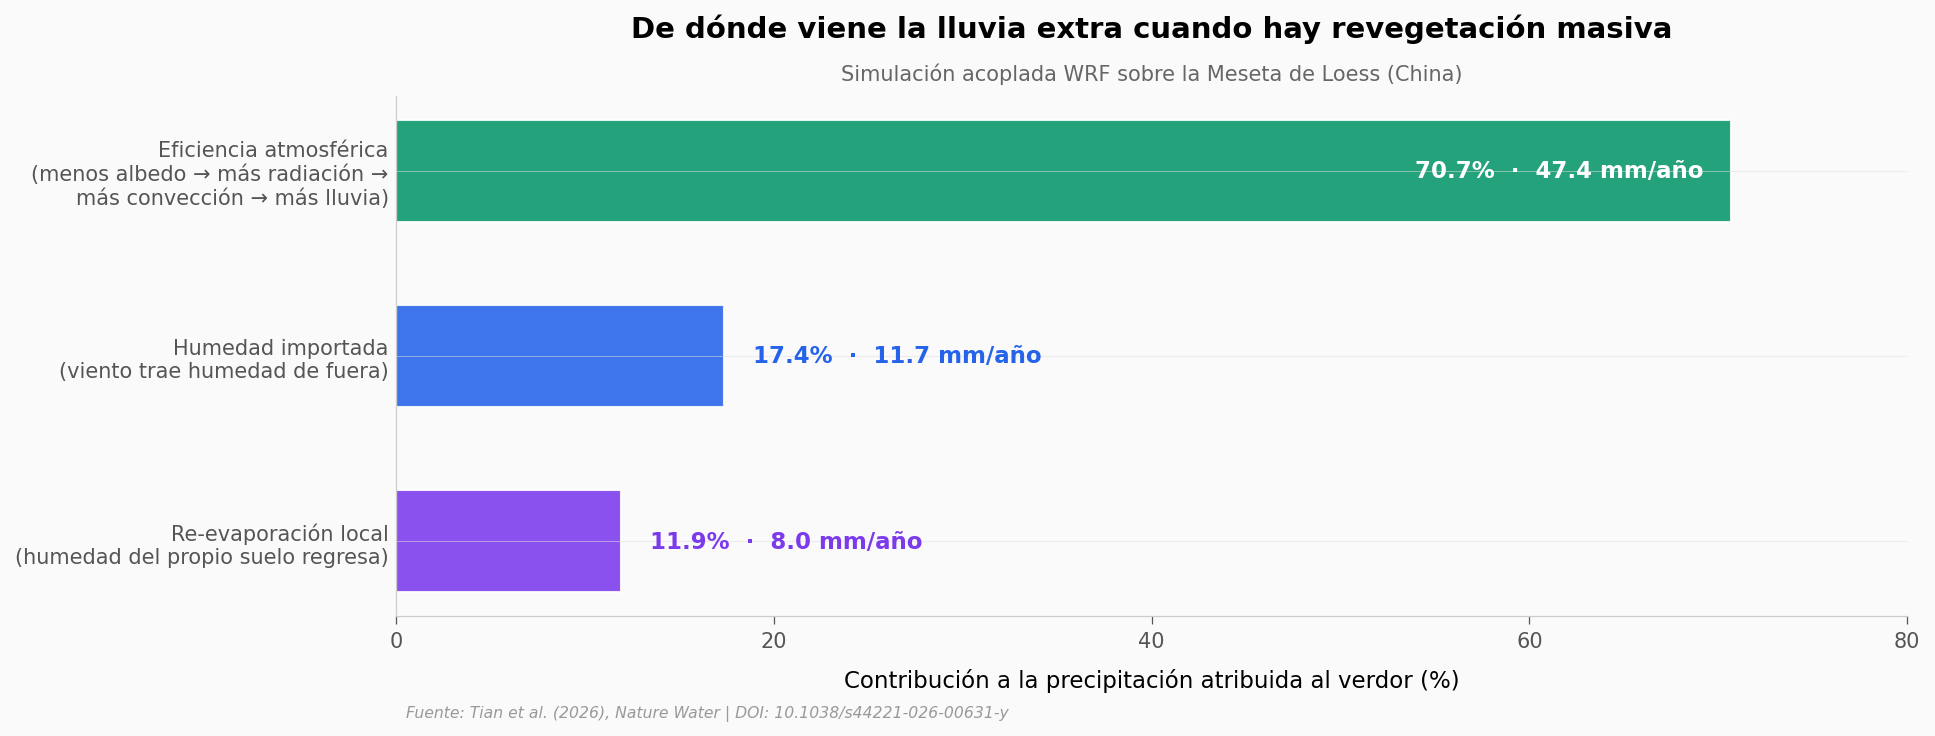

In [3]:
plt.close('all')
fig, ax = plt.subplots(figsize=(13, 4.5))

# Mapeo Term → label en español
term_labels = {
    'Efficiency': 'Eficiencia atmosférica\n(menos albedo → más radiación →\nmás convección → más lluvia)',
    'External':   'Humedad importada\n(viento trae humedad de fuera)',
    'Local':      'Re-evaporación local\n(humedad del propio suelo regresa)',
}
term_colors = {
    'Efficiency': COLOR_GREEN,
    'External':   COLOR_DATA,
    'Local':      COLOR_CONTEXT,
}

# Ordenar por contribución descendente
lp_sorted = lp.sort_values('Contribution(%)', ascending=True)

y_pos = np.arange(len(lp_sorted))
for i, (_, row) in enumerate(lp_sorted.iterrows()):
    color = term_colors[row['Term']]
    ax.barh(y_pos[i], row['Contribution(%)'], height=0.55,
            color=color, alpha=0.88, edgecolor='white', linewidth=1.0)
    # Etiqueta: dentro si la barra es ancha, fuera si no
    label = f'{row["Contribution(%)"]:.1f}%  ·  {row["Magnitude(mm/yr)"]:.1f} mm/año'
    if row['Contribution(%)'] >= 25:
        ax.text(row['Contribution(%)'] - 1.5, y_pos[i], label,
                ha='right', va='center', fontsize=11, fontweight='bold', color='white')
    else:
        ax.text(row['Contribution(%)'] + 1.5, y_pos[i], label,
                ha='left', va='center', fontsize=11, fontweight='bold', color=color)

ax.set_yticks(y_pos)
ax.set_yticklabels([term_labels[t] for t in lp_sorted['Term']], fontsize=10)
ax.set_xlabel('Contribución a la precipitación atribuida al verdor (%)', fontsize=11)
ax.set_xlim(0, 80)
ax.set_xticks([0, 20, 40, 60, 80])
ax.set_title('De dónde viene la lluvia extra cuando hay revegetación masiva',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Simulación acoplada WRF sobre la Meseta de Loess (China)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/lp_descomposicion.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)


## ¿Es un caso aislado o el patrón se repite?

La eficiencia atmosférica explica el **70,7%** del aumento de precipitación en la Meseta de Loess. Pero un solo caso no basta. El paper aplica el mismo análisis a otros cuatro puntos calientes de revegetación global: India, Australia, México y Estados Unidos.


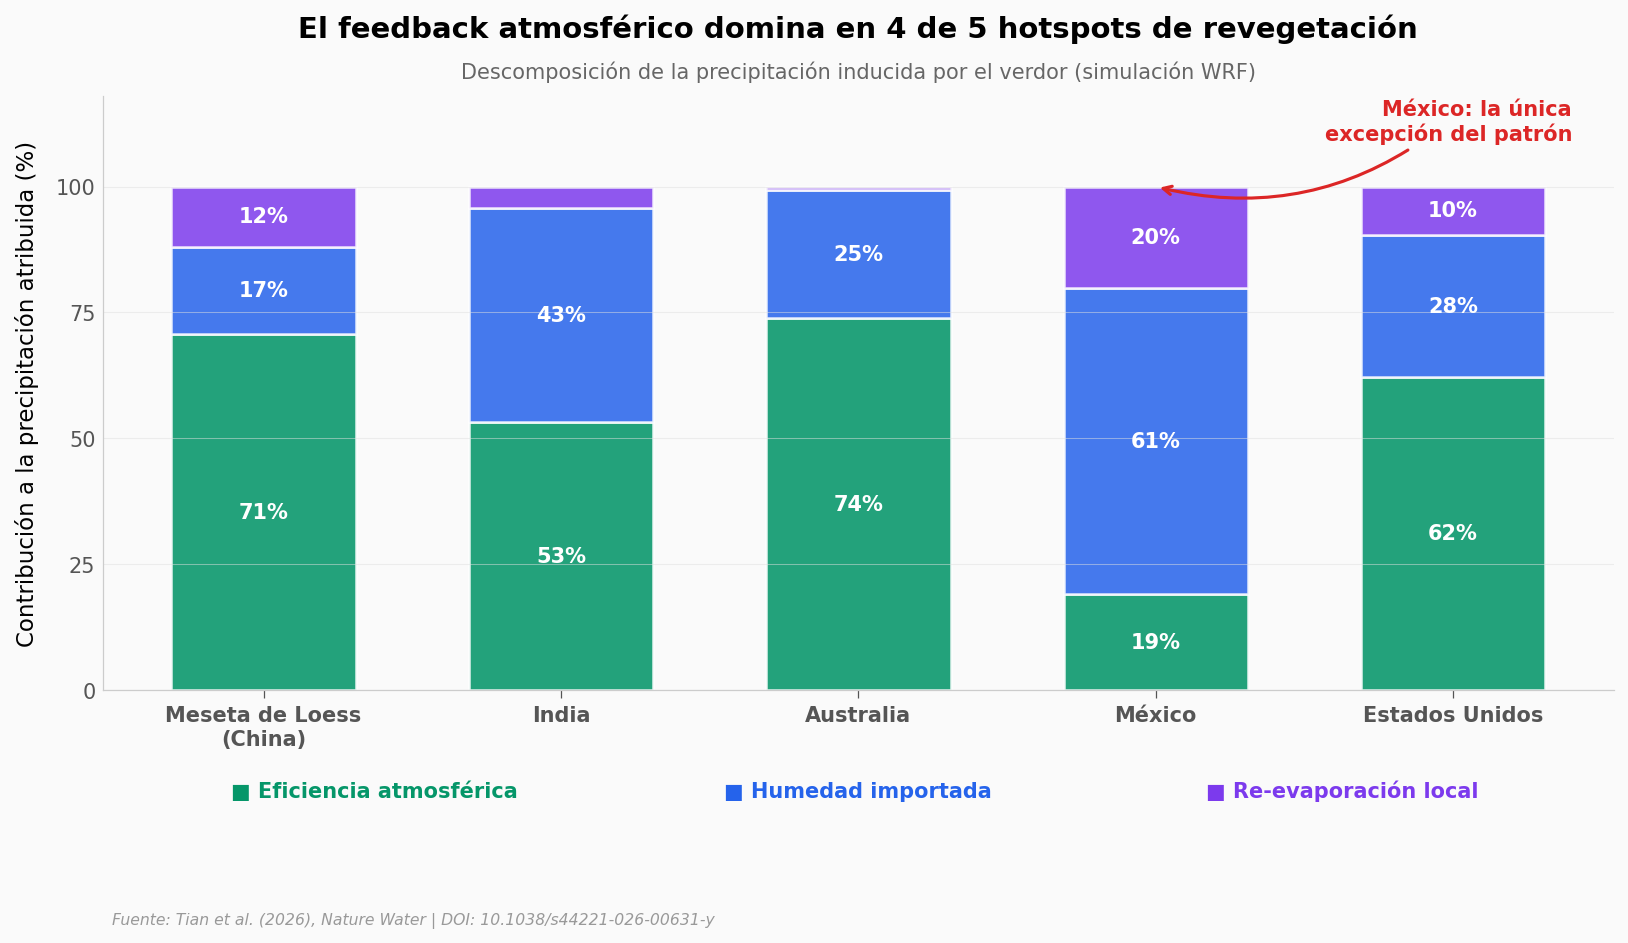

In [4]:
plt.close('all')
fig, ax = plt.subplots(figsize=(13, 6))

regiones_es = {
    'Loess Plateau': 'Meseta de Loess\n(China)',
    'India': 'India',
    'Australia': 'Australia',
    'Mexico': 'México',
    'United States': 'Estados Unidos',
}
orden_hot = ['Loess Plateau', 'India', 'Australia', 'Mexico', 'United States']

# Pivot a wide
pivot = hotspots.pivot(index='Region', columns='Term', values='Contribution(%)').loc[orden_hot]

x = np.arange(len(orden_hot))
width = 0.62

eff = pivot['Efficiency'].values
ext = pivot['External'].values
loc = pivot['Local'].values

ax.bar(x, eff, width, color=COLOR_GREEN, alpha=0.88, edgecolor='white', linewidth=1.2)
ax.bar(x, ext, width, bottom=eff, color=COLOR_DATA, alpha=0.85, edgecolor='white', linewidth=1.2)
ax.bar(x, loc, width, bottom=eff + ext, color=COLOR_CONTEXT, alpha=0.85, edgecolor='white', linewidth=1.2)

# Etiquetas % dentro de los segmentos (solo si caben, > 6%)
for i in range(len(x)):
    if eff[i] > 6:
        ax.text(i, eff[i]/2, f'{eff[i]:.0f}%', ha='center', va='center',
                fontsize=10, fontweight='bold', color='white')
    if ext[i] > 6:
        ax.text(i, eff[i] + ext[i]/2, f'{ext[i]:.0f}%', ha='center', va='center',
                fontsize=10, fontweight='bold', color='white')
    if loc[i] > 6:
        ax.text(i, eff[i] + ext[i] + loc[i]/2, f'{loc[i]:.0f}%', ha='center', va='center',
                fontsize=10, fontweight='bold', color='white')

# Marcar México como excepción — flecha desde la barra hacia abajo a la derecha
ax.annotate('México: la única\nexcepción del patrón',
            xy=(3, 100), xytext=(4.4, 113),
            fontsize=10, fontweight='bold', color=COLOR_LOSS,
            ha='right', va='center',
            arrowprops=dict(arrowstyle='->', color=COLOR_LOSS, lw=1.5,
                            connectionstyle='arc3,rad=-0.25'))

ax.set_xticks(x)
ax.set_xticklabels([regiones_es[r] for r in orden_hot], fontsize=10, fontweight='bold')
ax.set_ylabel('Contribución a la precipitación atribuida (%)', fontsize=11)
ax.set_ylim(0, 118)
ax.set_yticks([0, 25, 50, 75, 100])
ax.set_title('El feedback atmosférico domina en 4 de 5 hotspots de revegetación',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Descomposición de la precipitación inducida por el verdor (simulación WRF)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Inline labels — bajo el eje, separados del cuerpo
fig.subplots_adjust(bottom=0.22)
ax.text(0.18, -0.18, '■ Eficiencia atmosférica', fontsize=10, color=COLOR_GREEN,
        fontweight='bold', ha='center', transform=ax.transAxes)
ax.text(0.50, -0.18, '■ Humedad importada', fontsize=10, color=COLOR_DATA,
        fontweight='bold', ha='center', transform=ax.transAxes)
ax.text(0.82, -0.18, '■ Re-evaporación local', fontsize=10, color=COLOR_CONTEXT,
        fontweight='bold', ha='center', transform=ax.transAxes)

fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hotspots_descomposicion.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)


## ¿Qué tan común es que el caudal suba?

Volvamos a las 4.080 cuencas globales. Si la idea tradicional fuera correcta, la distribución de tendencias del caudal debería estar mayormente en negativo. Veamos qué muestra la distribución real.


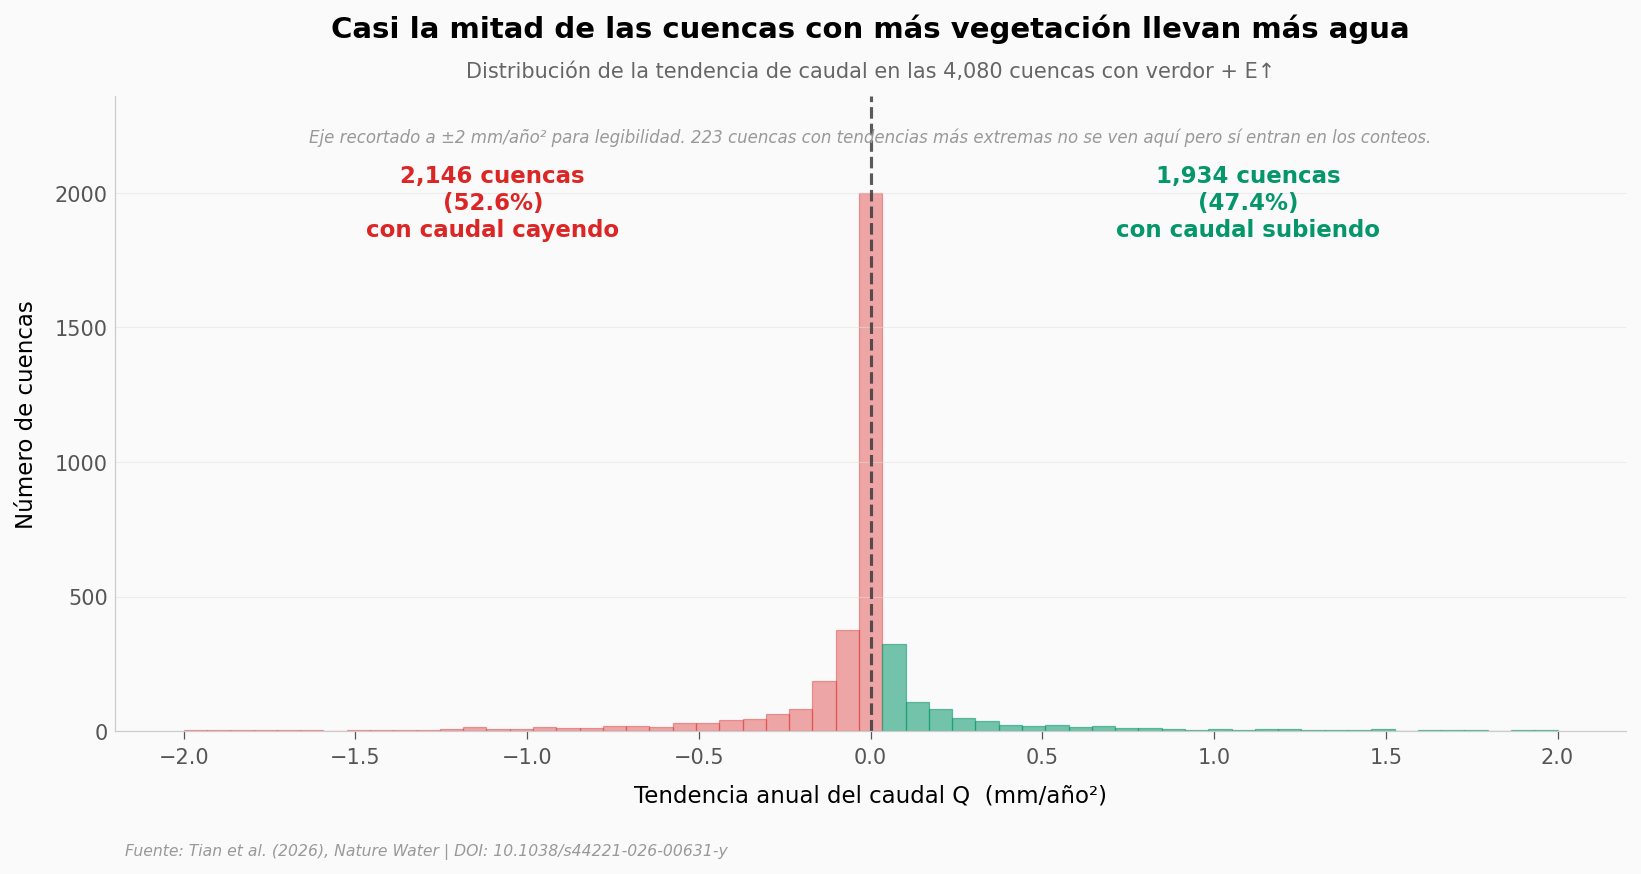

In [5]:
import gc
plt.close('all')
gc.collect()
fig, ax = plt.subplots(figsize=(13, 5.5))

q = cuencas['q_slope_mm_yr2'].values.copy()
# Zoom a [-2, 2] mm/año² — los datos están concentrados cerca de 0;
# outliers extremos (-113 a +327) se omiten visualmente pero los conteos del lateral
# usan TODA la población (4.080 cuencas).
p_lo, p_hi = -2.0, 2.0
q_clip = q[(q >= p_lo) & (q <= p_hi)]
n_visible = len(q_clip)
n_outliers = len(q) - n_visible

n_pos = (q > 0).sum()
n_neg = (q <= 0).sum()
pct_pos = n_pos / len(q) * 100

bins = np.linspace(p_lo, p_hi, 60)
n, bin_edges, patches = ax.hist(q_clip, bins=bins, color=COLOR_DATA, alpha=0.45,
                                edgecolor=COLOR_DATA, linewidth=0.6)
# Pintar negativos en rojo claro y positivos en verde
for patch, left in zip(patches, bin_edges[:-1]):
    if left >= 0:
        patch.set_facecolor(COLOR_GREEN)
        patch.set_edgecolor(COLOR_GREEN)
        patch.set_alpha(0.55)
    else:
        patch.set_facecolor(COLOR_LOSS)
        patch.set_edgecolor(COLOR_LOSS)
        patch.set_alpha(0.40)

y_max = n.max() * 1.18
ax.set_ylim(0, y_max)
ax.axvline(0, color='#333333', linewidth=1.5, linestyle='--', alpha=0.8)

ax.text(p_hi*0.55, y_max*0.78, f'{n_pos:,} cuencas\n({pct_pos:.1f}%)\ncon caudal subiendo',
        fontsize=11, fontweight='bold', color=COLOR_GREEN, ha='center')
ax.text(p_lo*0.55, y_max*0.78, f'{n_neg:,} cuencas\n({100-pct_pos:.1f}%)\ncon caudal cayendo',
        fontsize=11, fontweight='bold', color=COLOR_LOSS, ha='center')

# Nota sobre los outliers que se salen del zoom
ax.text(0.5, 0.95,
        f'Eje recortado a ±2 mm/año² para legibilidad. {n_outliers:,} cuencas con tendencias más extremas no se ven aquí pero sí entran en los conteos.',
        transform=ax.transAxes, fontsize=8, color='#999999', style='italic', ha='center', va='top')

ax.set_xlabel('Tendencia anual del caudal Q  (mm/año²)', fontsize=11)
ax.set_ylabel('Número de cuencas', fontsize=11)
ax.set_title('Casi la mitad de las cuencas con más vegetación llevan más agua',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'Distribución de la tendencia de caudal en las {len(q):,} cuencas con verdor + E↑',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/distribucion_q_slope.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)


### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|:-----------:|---------|
| 47,4% de las cuencas con verdor + E↑ tienen también Q↑ | ✅ | 1.934 / 4.080. Coincide con la frase del *abstract*: "nearly half of greening catchments". Verificación cruzada: la suma por aridez (32 + 454 + 192 + 1.256 = 1.934) reproduce el dato. |
| El patrón se invierte entre zonas secas y húmedas | ✅ | Semiárido 71,9% (n=631) y árido 66,7% (n=48) tienen mayoría E↑Q↑. Húmedo 40,6% (n=3.090) tiene mayoría con caudal cayendo. La muestra árida es pequeña — la conclusión robusta es para semiárido. |
| En la Meseta de Loess, la "eficiencia atmosférica" explica ~71% del aumento de lluvia atribuido al verdor | ⚠️ Dentro de la simulación | 47,38 mm/año de 67,03 totales. El número viene de la simulación acoplada WRF, no de medición directa — el paper lo enmarca como atribución del modelo. |
| El feedback atmosférico domina en otros 4 hotspots globales | ⚠️ 4 de 5 | Loess Plateau, India, Australia y Estados Unidos tienen Eficiencia dominante. **México es la excepción**: 60,8% viene de humedad importada, no del feedback. La narrativa CaM mantiene "4 de 5", no "todos". |
| Modelos *offline* subestiman la E inducida por verdor en >50% | ⚠️ Dentro de la simulación | Cita exacta del *abstract*. Se compara coupled vs offline en la simulación, no contra observaciones independientes. |

> **Limitaciones a tener presentes:**
> - El conteo por aridez es **observacional** (4.080 cuencas con tendencias temporales) — los datos muestran asociación, no demuestran causalidad. La conclusión causal ("el verdor produce más lluvia") solo es válida dentro de la simulación acoplada.
> - El bin árido tiene n=48 — muestra pequeña, ruido alto. La conclusión robusta es para zonas semiáridas (n=631).
> - Las atribuciones de la simulación dependen del modelo WRF y de cómo está parametrizado el albedo — no son medición directa del fenómeno físico.
> - La descomposición de los 5 hotspots viene de simulaciones regionales separadas; "consistente" significa coherente con el mecanismo, no replicación experimental.


## Ahora tú

Tres preguntas para explorar los datos:

1. **¿Qué pasa si filtras solo las cuencas grandes?** El dataset trae `size_km2`. Las cuencas chicas pueden tener mucho ruido — ¿cambia el porcentaje E↑Q↑ si te quedas con las > 1.000 km²?
2. **¿La magnitud del caudal subiendo es proporcional a la del verdor?** Mira la correlación entre `lai_slope` y `q_slope_mm_yr2` en las cuencas con Q↑. ¿Es fuerte? ¿Es ruidosa?
3. **¿En qué parte del mundo están las cuencas con E↑Q↑?** El campo `basin` empieza con un código de país (`Chile_...`, `US_...`, etc.). ¿Hay países dominantes?

La celda siguiente trae código pre-escrito para empezar.


In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: filtrar por tamaño
umbral_km2 = 1000  # Cambia este valor

grandes = cuencas[cuencas['size_km2'] >= umbral_km2]
n_grandes = len(grandes)
n_grandes_q_sube = (grandes['q_slope_mm_yr2'] > 0).sum()
pct_grandes = n_grandes_q_sube / n_grandes * 100 if n_grandes else 0

print(f'Cuencas ≥ {umbral_km2:,} km²: {n_grandes:,}')
print(f'  con Q↑: {n_grandes_q_sube:,} ({pct_grandes:.1f}%)')
print(f'Comparación — todas las cuencas: {(cuencas["q_slope_mm_yr2"] > 0).mean()*100:.1f}%')

# Pregunta 3: top 5 países por número de cuencas con Q↑
cuencas_q_sube = cuencas[cuencas['q_slope_mm_yr2'] > 0].copy()
cuencas_q_sube['pais'] = cuencas_q_sube['basin'].str.split('_').str[0]
top_paises = cuencas_q_sube['pais'].value_counts().head(5)
print('\nTop 5 países con cuencas E↑Q↑:')
for pais, n in top_paises.items():
    print(f'  {pais}: {n:,}')


Cuencas ≥ 1,000 km²: 2,678
  con Q↑: 1,230 (45.9%)
Comparación — todas las cuencas: 47.4%

Top 5 países con cuencas E↑Q↑:
  USGS: 842
  GRDC: 358
  Canada: 264
  Brazil: 208
  IN: 106


## Fuentes

**Paper**: [Energy-mediated feedbacks of vegetation greening enhance precipitation efficiency and sustain water yield in global semi-arid regions](https://doi.org/10.1038/s44221-026-00631-y)  
*Nature Water, 2026-04-22*

**Source Data**:  
- [Fig. 1 — LAI, Q, E slopes (4080 catchments)](https://static-content.springer.com/esm/art%3A10.1038%2Fs44221-026-00631-y/MediaObjects/44221_2026_631_MOESM3_ESM.xlsx)  
- [Fig. 4 — Loess Plateau decomposition](https://static-content.springer.com/esm/art%3A10.1038%2Fs44221-026-00631-y/MediaObjects/44221_2026_631_MOESM6_ESM.xlsx)  
- [Fig. 5 — Five global hotspots](https://static-content.springer.com/esm/art%3A10.1038%2Fs44221-026-00631-y/MediaObjects/44221_2026_631_MOESM7_ESM.xlsx)

*14 afirmaciones del notebook verificadas contra estas fuentes*

---

**Datos**: Source Data Figs. 1, 4 y 5 del artículo (Springer Nature MOESM3, MOESM6, MOESM7).
**Repo**: [Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) — notebook reproducible.
**Licencia**: CC BY 4.0.
